<a href="https://colab.research.google.com/github/ShivanshuK12399/Customer-Churn-Dataset/blob/main/Customer_Churn_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Set the path to the file you'd like to load
file_path=kagglehub.dataset_download("blastchar/telco-customer-churn")
print("path:",file_path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
path: /kaggle/input/telco-customer-churn


Preprocessing / Cleaning

In [ ]:
import pandas as pd

data_file=pd.read_csv(file_path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df=data_file

print(f"Shape {df.shape}\n")
# df.info()
# print(f"Total null values in DataFrame {df.isnull().sum().sum()}\n")
df.head()

#deleting useless data
df.drop(columns=['customerID'],inplace=True)

#types of values in these columns
col=["MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
# print(f"Unique values in columns:")
# for c in col:
  # print(f"{c} {df[c].unique()}")
# print()

#data types of numerical columns
col=df[["tenure","MonthlyCharges","TotalCharges"]]
# print(f"Data types of columns:")
# for c in col:
  # print(c,": ",df[c].dtype)
# print()

# changing datatypes
# print(df['TotalCharges'].apply(type).value_counts())
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce") # row 488 has Nan value
df.dropna(inplace=True) # Drop rows with any NaN values and update df
# print(f"Shape after dropping NaN values: {df.shape}")

# changing values
df['SeniorCitizen']=df['SeniorCitizen'].apply(lambda x: 'Yes' if(x==1) else 'No')

df.head(5)

Shape (7043, 21)



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Correlation

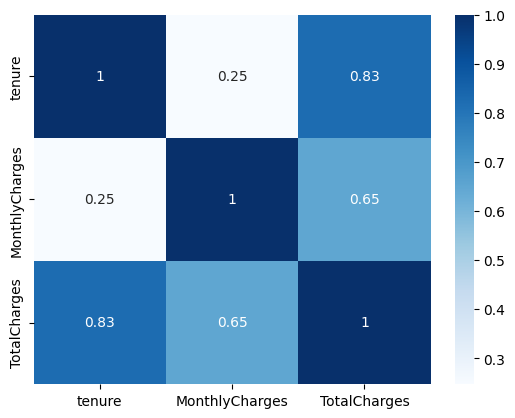

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

Percentages

In [ ]:
#Chrun rate
churn_rate=df["Churn"].value_counts(normalize=True)
print(f"{churn_rate.apply(lambda x: f"{round(x*100,2)}%")}")

churn_tenure=df.groupby('Churn')['tenure'].mean()
print(f"\nTenure mean of customers who churned:\n{round(churn_tenure,2).to_string(header=False)}")

churn_mcharges=df.groupby('Churn')['MonthlyCharges'].mean()
print(f"\nMonthly charges:\n{round(churn_mcharges,2).to_string(header=False)}")


#Some Columns info
print(f"\nColumns with two Values: {[col for col in df.columns if df[col].nunique() == 2]}")

num_cols=df.select_dtypes(include=['int64','float64']).columns
print("Numerical columns: ",num_cols)

Churn
No     73.42%
Yes    26.58%
Name: proportion, dtype: object

Tenure mean of customers who churned:
No     37.65
Yes    17.98

Monthly charges:
No     61.31
Yes    74.44

Columns with two Values: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Numerical columns:  Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

# Spliting data
x=df.drop(columns='Churn')
y=df['Churn']

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=6)

Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

lb=LabelEncoder()

# Label Encoding for x_train (columns with two unique values)
for col in x_train.columns:
  if(x_train[col].nunique()==2):
    x_train[col]=lb.fit_transform(x_train[col])
    x_test[col]=lb.transform(x_test[col])

# Label Encoding for the target variable y_train and y_test
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

# One-hot encoding for x_train and x_test (columns with more than two unique categorical values)
x_train=pd.get_dummies(x_train,x_train.select_dtypes(include='object').columns)
x_train[x_train.select_dtypes(include='object').columns]=x_train[x_train.select_dtypes(include='object').columns].astype(int)

x_test=pd.get_dummies(x_test,x_test.select_dtypes(include='object').columns)
x_test[x_test.select_dtypes(include='object').columns]=x_test[x_test.select_dtypes(include='object').columns].astype(int)

x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1156,0,0,0,0,53,1,0,18.70,1005.70,True,...,False,True,False,False,False,True,False,False,False,True
1948,0,0,0,0,2,1,0,80.75,159.45,True,...,False,False,True,True,False,False,False,False,True,False
3041,1,0,0,1,1,1,1,49.90,49.90,True,...,True,False,False,True,False,False,False,False,True,False
6413,0,0,1,1,32,1,1,91.05,2954.50,False,...,False,False,True,True,False,False,True,False,False,False
2033,1,0,0,0,1,1,1,20.20,20.20,True,...,False,True,False,True,False,False,False,False,False,True


### Correlation of All Preprocessed Features

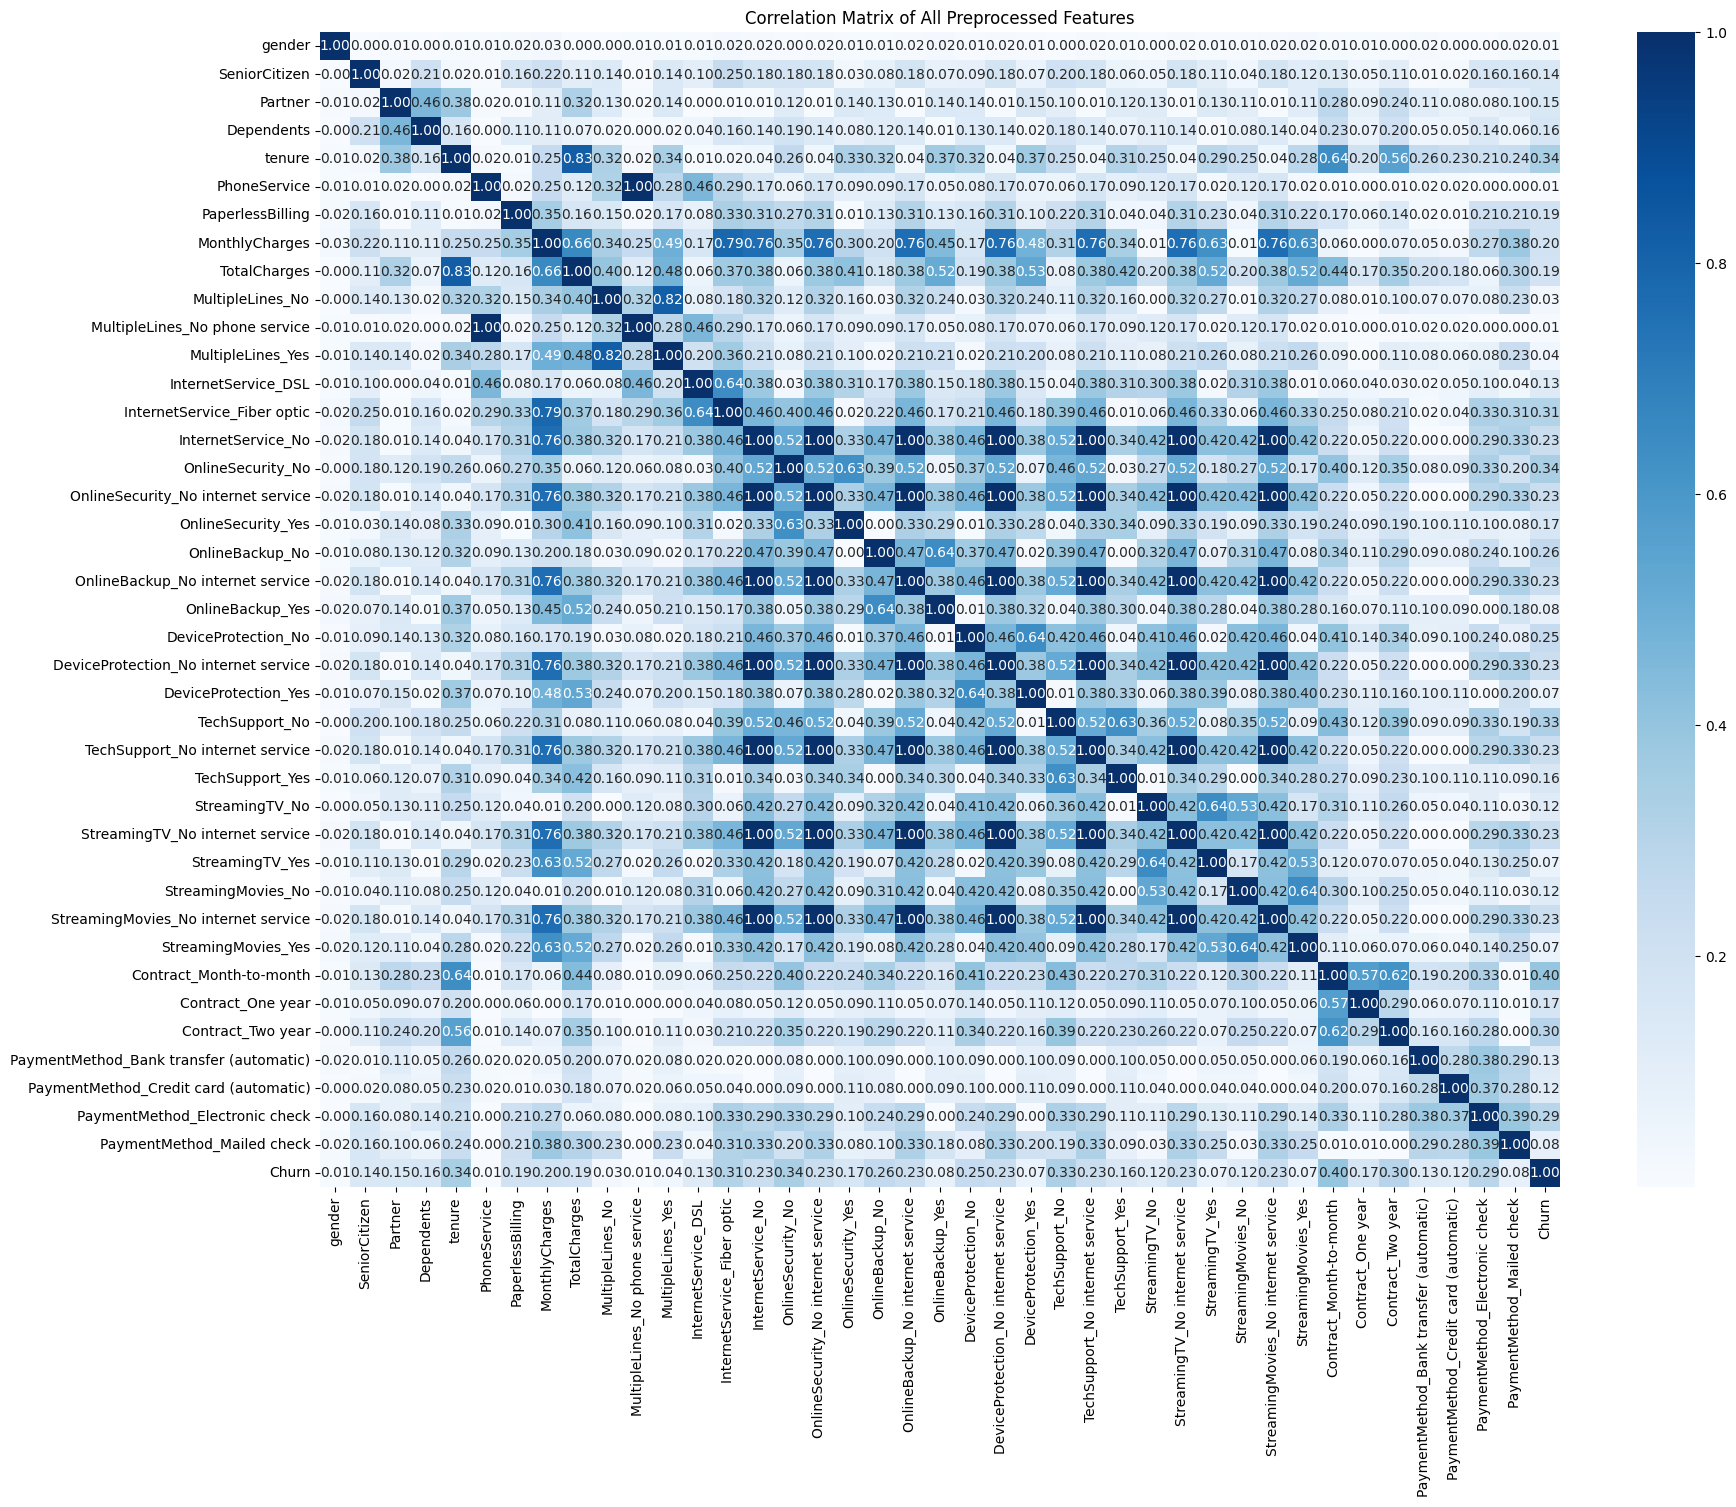

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine preprocessed x_train and y_train to calculate correlation of all features
# Ensure y_train is a Series with the correct index and name
churn_series = pd.Series(y_train, index=x_train.index, name='Churn')
all_features_df = pd.concat([x_train, churn_series], axis=1)

# Calculate the correlation matrix for all features
corr_all_features = all_features_df.corr().abs()

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_all_features, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix of All Preprocessed Features')
plt.show()

Deleting correalted features

In [ ]:
import numpy as np

corr=all_features_df.corr().abs()

matrix=np.ones(corr.shape)       # Create a matrix of 1s
upper_matrix=np.triu(matrix,k=1) # keep only upper triangle, k=1 removes the diagonal
mask=upper_matrix.astype(bool)
upper=corr.where(mask)           # apply masking

to_drop = [col for col in upper.columns if any(upper[col]>0.85)]
# print(f"Columns to drop due to high correlation: {to_drop}")

# x_train = x_train.drop(columns=to_drop)
# x_test=x_test.drop(columns=to_drop)
x_train.head()

Columns to drop due to high correlation: ['MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1156,0,0,0,0,53,1,0,18.70,1005.70,True,...,False,True,False,False,False,True,False,False,False,True
1948,0,0,0,0,2,1,0,80.75,159.45,True,...,False,False,True,True,False,False,False,False,True,False
3041,1,0,0,1,1,1,1,49.90,49.90,True,...,True,False,False,True,False,False,False,False,True,False
6413,0,0,1,1,32,1,1,91.05,2954.50,False,...,False,False,True,True,False,False,True,False,False,False
2033,1,0,0,0,1,1,1,20.20,20.20,True,...,False,True,False,True,False,False,False,False,False,True


Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])

# print(x_train[num_cols].mean(),"\n")
# print(x_train[num_cols].std())

Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

model=LogisticRegression(class_weight='balanced',max_iter=1000)

scores = cross_val_score(model, x_train, y_train, cv=StratifiedKFold(n_splits=5), scoring='roc_auc')
print(np.round(scores.mean(),2))

model.fit(x_train,y_train)
y_pred=model.predict(x_test)

y_pred_prob = model.predict_proba(x_test)[:,1]
print(roc_auc_score(y_test, y_pred_prob))

0.84
0.8637285308452136


Plotting

Correct predictions: 1075
False predictions: 332



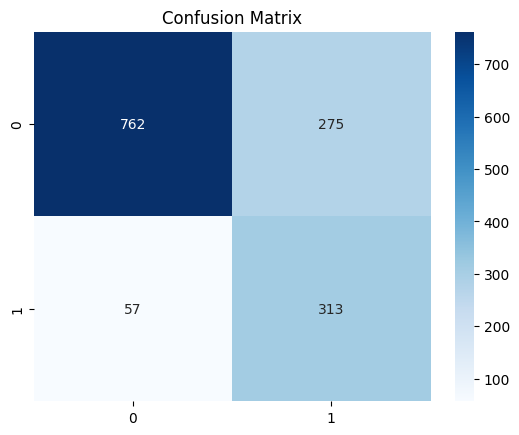

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1037
           1       0.53      0.85      0.65       370

    accuracy                           0.76      1407
   macro avg       0.73      0.79      0.74      1407
weighted avg       0.83      0.76      0.78      1407



In [ ]:
con_matrix=confusion_matrix(y_test,y_pred)
print(f"Correct predictions: {con_matrix[0,0]+con_matrix[1,1]}")
print(f"False predictions: {con_matrix[0,1]+con_matrix[1,0]}\n")

sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test,y_pred))